<a href="https://colab.research.google.com/github/Overlord15/Deep-Learning-Lab-IA1/blob/main/TransferLearning_MobileNetV2_CIFAR10_IA1_dense169.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


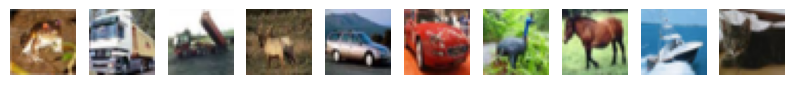

In [1]:
#Step 0: Visualise the Dataset
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (_, _) = cifar10.load_data()

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.show()


In [2]:
#step 1- Load in CIFAR-10
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.densenet import preprocess_input


from tensorflow.keras.utils import to_categorical

#load in CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
'''
#step 2 - Resize for MobileNetV2 (224x224)
from tensorflow.image import resize

X_train = tf.image.resize(X_train, [224, 224])
X_test = tf.image.resize(X_test, [224, 224])
'''

'\n#step 2 - Resize for MobileNetV2 (224x224)\nfrom tensorflow.image import resize\n\nX_train = tf.image.resize(X_train, [224, 224])\nX_test = tf.image.resize(X_test, [224, 224])\n'

In [4]:
#step 2.1 - (fix) Resize for DenseNet169 (224x224)

import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

#preprocessing function for map
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, tf.one_hot(label[0], 10)

#train dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#test dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
from tensorflow.keras.applications import DenseNet169

# Step 3 - Load DenseNet169 without top classification head
base_model_densenet169 = DenseNet169(weights='imagenet',
                                  include_top=False,
                                  input_shape=(224, 224, 3))

base_model_densenet169.trainable = False

'''
from tensorflow.keras.applications import ResNet50
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_resnet50.trainable = False

from tensorflow.keras.applications import VGG16
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_vgg16.trainable = False
'''

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


"\nfrom tensorflow.keras.applications import ResNet50\nbase_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))\nbase_model_resnet50.trainable = False\n\nfrom tensorflow.keras.applications import VGG16\nbase_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))\nbase_model_vgg16.trainable = False\n"

In [6]:
#Step 4 - Adding our custom top classification head
from tensorflow.keras import layers, models

#custom head for DenseNet169
model_densenet169 = models.Sequential([
    base_model_densenet169,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

#compile the model
model_densenet169.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
#Step 5 - Train DenseNet169
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('densenet169_cifar10.keras', save_best_only=True)

#train the model
history = model_densenet169.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 299s 166ms/step - accuracy: 0.8148 - loss: 0.5551 - val_accuracy: 0.8859 - val_loss: 0.3364
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 187s 120ms/step - accuracy: 0.8626 - loss: 0.4064 - val_accuracy: 0.8873 - val_loss: 0.3245
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 119ms/step - accuracy: 0.8746 - loss: 0.3721 - val_accuracy: 0.8909 - val_loss: 0.3211
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 120ms/step - accuracy: 0.8806 - loss: 0.3507 - val_accuracy: 0.8897 - val_loss: 0.3146
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.8849 - loss: 0.3368 - val_accuracy: 0.8929 - val_loss: 0.3136
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 187s 120ms/step - accuracy: 0.8886 - loss: 0.3277 - val_accuracy: 0.8955 - val_loss: 0.3081
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 185s 118ms/step - accuracy: 0.8941 - loss: 0.3089 - val_accuracy: 0.8968 - val_loss: 0.3162
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 185s 118ms/step - ac

In [8]:
#Step 6 - performance evaluation
loss, acc = model_densenet169.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.8984 - loss: 0.3056
Test Accuracy: 0.90


In [10]:
#Step 7 - fine tune DenseNet169
base_model_densenet169.trainable = True

model_densenet169.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 5
total_epochs = 10 + fine_tune_epochs

history_fine = model_densenet169.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=10,
    validation_data=test_ds
)

Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1151s 561ms/step - accuracy: 0.8602 - loss: 0.4917 - val_accuracy: 0.9385 - val_loss: 0.1953
Epoch 12/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 660s 422ms/step - accuracy: 0.9411 - loss: 0.1789 - val_accuracy: 0.9466 - val_loss: 0.1771
Epoch 13/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 674s 417ms/step - accuracy: 0.9669 - loss: 0.0952 - val_accuracy: 0.9523 - val_loss: 0.1763
Epoch 14/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 685s 419ms/step - accuracy: 0.9826 - loss: 0.0530 - val_accuracy: 0.9542 - val_loss: 0.1938
Epoch 15/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 658s 421ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9594 - val_loss: 0.1917


In [11]:
#Step 8 - evaluate again
loss, acc = model_densenet169.evaluate(test_ds)
print(f"Fine-tuned Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.9594 - loss: 0.1917
Fine-tuned Test Accuracy: 0.96


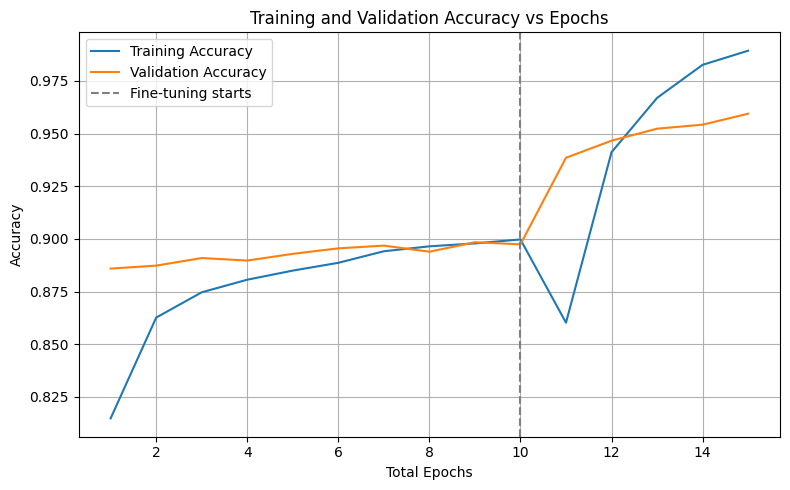

In [12]:
# Q(c) Plot final accuracies (training and validation) vs total epochs

total_acc     = history.history['accuracy']     + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(range(1, total_epochs + 1), total_acc,     label='Training Accuracy')
plt.plot(range(1, total_epochs + 1), total_val_acc, label='Validation Accuracy')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()